In [1]:
import xarray as xr
import rioxarray
import numpy as np
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature  # Add this import
from matplotlib.colors import BoundaryNorm
from cartopy.util import add_cyclic_point
from datetime import datetime
from matplotlib.colors import LogNorm
import matplotlib.colors as colors

C:\Users\haley\AppData\Roaming\Python\Python39\site-packages\scipy\__init__.py:177: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"

Bad key "mathtext.fallback" on line 160 in
C:\Users\haley\AppData\Roaming\Python\Python39\site-packages\matplotlib\mpl-data\stylelib\classic (2).mplstyle.
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.2.2/matplotlibrc.template
or from the matplotlib source distribution

Bad key "axes.titley" on line 181 in
C:\Users\haley\AppData\Roaming\Python\Python39\site-packages\matplotlib\mpl-data\stylelib\classic (2).mplstyle.
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.2.2/matplotlibrc.template
or from the matplotlib source distribution

Bad key "date.converter" on line 235 in
C:\Users\haley\AppData\Roami

In [8]:
directory = 'C:/Users/haley/OneDrive/Graduate/Research/pyhhb/'
ds = xr.open_dataset(directory + 'wang_et_al_2022/SSP2/SPP2/SSP2_2020.nc')

In [ ]:
def wang_regridder(ds):
    
    # Ensure the dataset has spatial coordinates
    ds = ds.rio.write_crs("EPSG:4326")

    # Identify the variable containing population data
    pop_var = 'Band1'  # Replace with your actual variable name

    # Calculate the original total population
    original_total = ds[pop_var].sum().values

    # Define the new resolution and create new lat/lon coordinates
    new_res = 0.25  # 0.25 degrees
    new_lon = np.arange(-180, 180.25, new_res)
    new_lat = np.arange(84, -72.25, -new_res)  # Reverse order for latitude

    # Perform the resampling
    resampled = ds[pop_var].rio.reproject(
        ds.rio.crs,
        shape=(len(new_lat), len(new_lon)),
        resampling=Resampling.sum
    )

    # Assign new coordinates
    resampled = resampled.assign_coords(
        x=('x', new_lon),
        y=('y', new_lat)
    )

    # Rename dimensions to lat and lon if needed
    resampled = resampled.rename({'y': 'lat', 'x': 'lon'})

    # Calculate the resampled total and the scaling factor
    resampled_total = resampled.sum().values

    # Verify the totals and shape
    print(f"Original total: {original_total}")
    print(f"Resampled total: {resampled_total}")
    print(f"Resampled shape: {resampled.shape}")

    # Create a new dataset with the resampled data
    new_ds = xr.Dataset({pop_var: resampled})
    
    del new_ds.Band1.attrs['grid_mapping']
    
    return new_ds

In [ ]:
new_ds = wang_regridder(ds)

In [ ]:
new_ds.to_netcdf(directory + 'wang_et_al_2022/SSP2/SPP2/SSP2_2020_regridded.nc')

# Olde zone, some plotting attempts

In [9]:
# Ensure the dataset has spatial coordinates
ds = ds.rio.write_crs("EPSG:4326")

# Identify the variable containing population data
pop_var = 'Band1'  # Replace with your actual variable name

# Calculate the original total population
original_total = ds[pop_var].sum().values

# Define the new resolution and create new lat/lon coordinates
new_res = 0.25  # 0.25 degrees
new_lon = np.arange(-180, 180.25, new_res)
new_lat = np.arange(84, -72.25, -new_res)  # Reverse order for latitude

# Perform the resampling
resampled = ds[pop_var].rio.reproject(
    ds.rio.crs,
    shape=(len(new_lat), len(new_lon)),
    resampling=Resampling.sum
)

# Assign new coordinates
resampled = resampled.assign_coords(
    x=('x', new_lon),
    y=('y', new_lat)
)

# Rename dimensions to lat and lon if needed
resampled = resampled.rename({'y': 'lat', 'x': 'lon'})

# Calculate the resampled total and the scaling factor
resampled_total = resampled.sum().values
# scaling_factor = original_total / resampled_total

# Apply the scaling factor to ensure the total population is preserved
# resampled = resampled * scaling_factor

# Verify the totals and shape
print(f"Original total: {original_total}")
print(f"Resampled total: {resampled_total}")
# print(f"Resampled total after scaling: {resampled.sum().values}")
print(f"Resampled shape: {resampled.shape}")

# Create a new dataset with the resampled data
new_ds = xr.Dataset({pop_var: resampled})

Original total: 7658792960.0
Resampled total: 7658909696.0
Resampled shape: (625, 1441)


In [10]:
del new_ds.Band1.attrs['grid_mapping']

In [11]:
# Save the new dataset
new_ds.to_netcdf(directory + 'wang_et_al_2022/SSP2/SPP2/SSP2_2020_regridded.nc')

In [6]:
new_ds

<xarray.Dataset>
Dimensions:  (lon: 1440, lat: 625)
Coordinates:
    crs      int32 0
  * lon      (lon) float64 0.0 0.25 0.5 0.75 1.0 ... 359.0 359.2 359.5 359.8
  * lat      (lat) float64 84.0 83.75 83.5 83.25 ... -71.25 -71.5 -71.75 -72.0
Data variables:
    Band1    (lat, lon) float32 nan nan nan nan nan nan ... nan nan nan nan nan

In [7]:
ds

<xarray.Dataset>
Dimensions:  (lat: 18720, lon: 43200)
Coordinates:
    crs      int32 0
  * lat      (lat) float64 -72.0 -71.99 -71.98 -71.97 ... 83.97 83.98 83.99 84.0
  * lon      (lon) float64 -180.0 -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
Data variables:
    Band1    (lat, lon) float32 nan nan nan nan nan nan ... nan nan nan nan nan
Attributes:
    Conventions:  CF-1.5
    GDAL:         GDAL 3.6.2, released 2023/01/02
    history:      Thu Mar 13 07:58:21 2025: GDAL CreateCopy( SSP2_2020.nc, ... )

In [5]:
def cyclic_wrapper(x, dim = "longitude"):
    """So add_cyclic_point() works on 'dim' via xarray Dataset.map()"""
    wrap_data, wrap_lon = add_cyclic_point(x.values, coord = x.coords[dim].data, 
                                           axis = x.dims.index(dim))
    
    return xr.DataArray(wrap_data, coords = {dim : wrap_lon, **x.drop(dim).coords}, dims = x.dims)

In [6]:
ds = xr.open_dataset('resampled_population_' + year + '.nc')

population = ds['Band1']

In [7]:
new_lats = np.arange(-72, 90.25, 0.25)  # Adjust the step size as needed

# Give a name to your original DataArray if it doesn't have one
population = population.rename('population')

extended_data = xr.DataArray(
    np.full((len(new_lats), population.sizes['lon']), np.nan),
    coords=[('lat', new_lats), ('lon', population.lon.values)],
    dims=['lat', 'lon'],
    name='extended_population'  # Give a name to the extended DataArray
)

result = xr.merge([population, extended_data])

result = result.fillna(population)

population = result['extended_population'].drop_vars('crs')

In [8]:
# Setting geography boundaries 
lat_min = -90
lat_max = 90
lon_min = -180
lon_max = 180

latitudes = population.coords['lat'].sel(lat = slice(lat_max, lat_min)).values 

longitudes = population.coords['lon'].sel(lon = slice(lon_min, lon_max)).values  

values_at_358_5 = population.sel(lon = 358.5)
values_at_1 = population.sel(lon = 1)

# Assign these values to longitude == 358.75
population.loc[dict(lon = 358.75)] = values_at_358_5
population.loc[dict(lon = 359)] = values_at_358_5
population.loc[dict(lon = 359.25)] = values_at_358_5
population.loc[dict(lon = 359.5)] = values_at_358_5
population.loc[dict(lon = 359.75)] = values_at_358_5

# Assign these values to longitude == 1
population.loc[dict(lon = 0)] = values_at_1
population.loc[dict(lon = 0.25)] = values_at_1
population.loc[dict(lon = 0.5)] = values_at_1
population.loc[dict(lon = 0.75)] = values_at_1

population = cyclic_wrapper(population, dim = 'lon')

population = population.sel(lat = slice(-60.0, 90))

# Assuming your DataArray is named 'population' and the coordinate you want to reverse is 'lat'
population = population.sel(lat = slice(None, None, -1))

latitudes = population.coords['lat'].sel(lat = slice(lat_max, lat_min)).values 

# longitudes = population.coords['lon'].sel(lon = slice(lon_min, lon_max)).values

population = population.rename({'lon' : 'longitude', 'lat' : 'latitude'})

total_pop = population

total_pop['longitude'] = total_pop['longitude'] - 180

longitudes = total_pop.coords['longitude'].sel(longitude = slice(lon_min, lon_max)).values

In [9]:
total_pop

<xarray.DataArray (latitude: 601, longitude: 1441)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * latitude   (latitude) float64 90.0 89.75 89.5 89.25 ... -59.5 -59.75 -60.0
  * longitude  (longitude) float64 -180.0 -179.8 -179.5 ... 179.5 179.8 180.0

In [10]:
total_pop.to_netcdf('total_pop_' + year + '.nc')

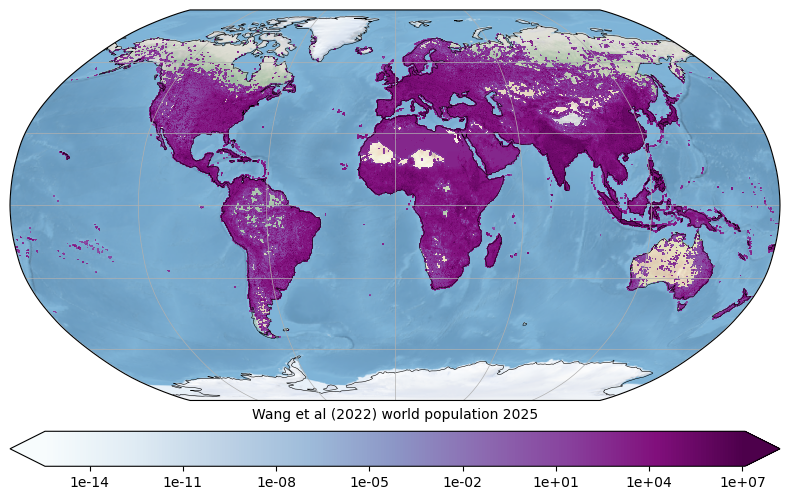

CPU times: total: 26.9 s
Wall time: 27.4 s


In [11]:
%%time

ssp = str(245)

title_colorbar = 'Wang et al (2022) world population 2025'
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
ax.stock_img()
ax.coastlines(lw=0.4)

# Extract the numpy array from the xarray DataArray
total_pop_array = total_pop.values

# Mask out non-positive values
total_pop_masked = np.ma.masked_less_equal(total_pop_array, 0)

# Define logarithmic levels
min_value = np.nanmin(total_pop_masked[~total_pop_masked.mask])  # Minimum non-zero value
max_value = np.nanmax(total_pop_masked)
levels = np.logspace(np.log10(min_value), np.log10(max_value), num=20)

cmap = plt.get_cmap('BuPu')
norm = colors.LogNorm(vmin=min_value, vmax=max_value)

filled_c = ax.pcolormesh(longitudes, latitudes, total_pop_masked,
                         transform=ccrs.PlateCarree(),
                         cmap='BuPu', norm=norm)

# Create tick locations for the colorbar
tick_locations = np.logspace(np.log10(min_value), np.log10(max_value), num=5)

clb = plt.colorbar(filled_c, orientation='horizontal', extend='both', pad=0.04,
                   ticks=tick_locations)

clb.set_label(title_colorbar, fontsize=10, labelpad=-59)
clb.ax.set_xscale('log')

# Format the tick labels to use scientific notation
clb.ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0e}'))

gl = ax.gridlines(draw_labels=False, linewidth=0.5)
gl.top_labels = False
gl.left_labels = False

fig.tight_layout()

plt.show()
plt.close()

In [12]:
print(f"Data range: {np.nanmin(total_pop_array)} to {np.nanmax(total_pop_array)}")
print(f"Number of non-positive values: {np.sum(total_pop_array <= 0)}")
print(f"Number of positive values: {np.sum(total_pop_array > 0)}")

Data range: 0.0 to 12126190.0
Number of non-positive values: 112489
Number of positive values: 154223


In [94]:
# # Ensure the dataset has spatial coordinates
# ds = ds.rio.write_crs("EPSG:4326")

# # Identify the variable containing population data
# pop_var = 'Band1'  # Replace with your actual variable name

# # Calculate the original total population
# original_total = ds[pop_var].sum().values

# # Define the new resolution and create new lat/lon coordinates
# new_res = 0.25  # 0.25 degrees
# new_lon = np.arange(0, 360, new_res)
# new_lat = np.arange(90, -90, -new_res)  # Reverse order for latitude

# # Perform the resampling
# resampled = ds[pop_var].rio.reproject(
#     ds.rio.crs,
#     resolution=(new_res, new_res),
#     resampling=Resampling.sum
# )

# # Adjust longitude values to 0-359.75 range if necessary
# if resampled.rio.x_dim == 'lon':
#     resampled = resampled.assign_coords(lon=(resampled.lon % 360))
#     resampled = resampled.roll(lon=(resampled.lon.size // 2), roll_coords=True)

# # Interpolate to the new grid
# resampled = resampled.interp(lat=new_lat, lon=new_lon, method='nearest')

# # Calculate the resampled total and the scaling factor
# resampled_total = resampled.sum().values
# scaling_factor = original_total / resampled_total

# # Apply the scaling factor to ensure the total population is preserved
# resampled = resampled * scaling_factor

# # Verify the totals and shape
# print(f"Original total: {original_total}")
# print(f"Resampled total before scaling: {resampled_total}")
# print(f"Resampled total after scaling: {resampled.sum().values}")
# print(f"Resampled shape: {resampled.shape}")

# # Create a new dataset with the resampled data
# new_ds = xr.Dataset({pop_var: resampled})

# # Save the new dataset
# new_ds.to_netcdf('resampled_population.nc')

In [3]:
# Ensure the dataset has spatial coordinates
ds = ds.rio.write_crs("EPSG:4326")

# Identify the variable containing population data
pop_var = 'Band1'  # Replace with your actual variable name

# Calculate the original total population
original_total = ds[pop_var].sum().values

# Define the new resolution
new_res = 0.25  # 0.25 degrees

# Perform the resampling
resampled = ds[pop_var].rio.reproject(
    ds.rio.crs,
    resolution=(new_res, new_res),
    resampling=Resampling.sum
)

# Calculate the resampled total and the scaling factor
resampled_total = resampled.sum().values
scaling_factor = original_total / resampled_total

# Apply the scaling factor to ensure the total population is preserved
resampled = resampled * scaling_factor

# Verify the totals
print(f"Original total: {original_total}")
print(f"Resampled total before scaling: {resampled_total}")
print(f"Resampled total after scaling: {resampled.sum().values}")

# Create a new dataset with the resampled data
new_ds = xr.Dataset({pop_var: resampled})

# Save the new dataset
new_ds.to_netcdf('resampled_population.nc')

Original total: 8005984768.0
Resampled total before scaling: 8005767168.0
Resampled total after scaling: 8005985280.0


In [4]:
data = xr.open_dataset('resampled_population.nc')

In [5]:
data

<xarray.Dataset>
Dimensions:  (x: 1440, y: 624)
Coordinates:
  * x        (x) float64 -179.9 -179.6 -179.4 -179.1 ... 179.1 179.4 179.6 179.9
  * y        (y) float64 83.87 83.62 83.37 83.12 ... -71.13 -71.38 -71.63 -71.88
    crs      int32 ...
Data variables:
    Band1    (y, x) float32 ...

In [4]:
# Ensure the dataset has spatial coordinates
ds = ds.rio.write_crs("EPSG:4326")

In [5]:
# Identify the variable containing population data
pop_var = 'Band1'  # Replace with your actual variable name

# Define the new resolution
new_res = 0.25  # 0.25 degrees

# Calculate the new dimensions
new_lat = np.arange(ds.lat.min(), ds.lat.max(), new_res)
new_lon = np.arange(ds.lon.min(), ds.lon.max(), new_res)

In [6]:
# Perform the resampling
resampled = ds[pop_var].rio.reproject(
    ds.rio.crs,
    resolution=(new_res, new_res),
    resampling=Resampling.sum
)

In [13]:
# Calculate the resampled total and the scaling factor
resampled_total = resampled.sum().values
scaling_factor = original_total / resampled_total

In [14]:
# Apply the scaling factor to ensure the total population is preserved
resampled = resampled * scaling_factor

In [15]:
# Verify the totals
print(f"Original total: {original_total}")
print(f"Resampled total before scaling: {resampled_total}")
print(f"Resampled total after scaling: {resampled.sum().values}")

Original total: 8005984768.0
Resampled total before scaling: 8005985280.0
Resampled total after scaling: 8005984768.0


In [16]:
# Create a new dataset with the resampled data
new_ds = xr.Dataset({pop_var: resampled})

# Save the new dataset
new_ds.to_netcdf('resampled_population.nc')

In [17]:
data = xr.open_dataset('resampled_population.nc')

In [7]:
# Ensure the total population is preserved
original_total = ds[pop_var].sum().values
resampled_total = resampled.sum().values
scaling_factor = original_total / resampled_total
resampled = resampled * scaling_factor

In [12]:
resampled_total

array(8.005767e+09, dtype=float32)

In [11]:
original_total

array(8.005985e+09, dtype=float32)

In [8]:
# Create a new dataset with the resampled data
new_ds = xr.Dataset({pop_var: resampled})

# Save the new dataset
new_ds.to_netcdf('resampled_population.nc')

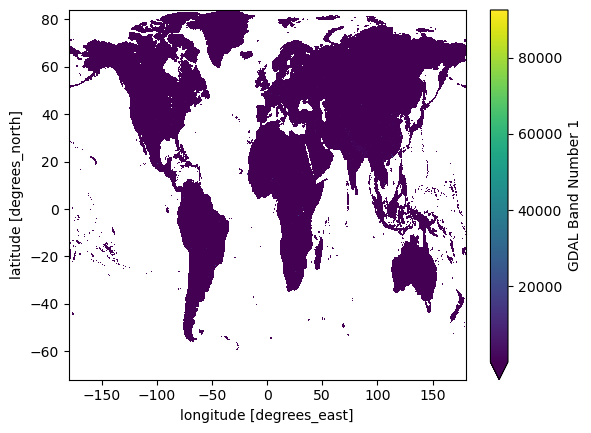

In [32]:
data['Band1'].plot(vmin = 100)